Kết quả trên tập Test:

o Độ chính xác (Accuracy): 60.00%

o Ma trận nhầm lẫn (Confusion Matrix):

[[2 3]
 [1 4]]

§ True Positive (Đoán đúng Chó): 2
§ True Negative (Đoán đúng Mèo): 4
§ False Positive (Nhầm Mèo thành Chó): 1
§ False Negative (Nhầm Chó thành Mèo): 3


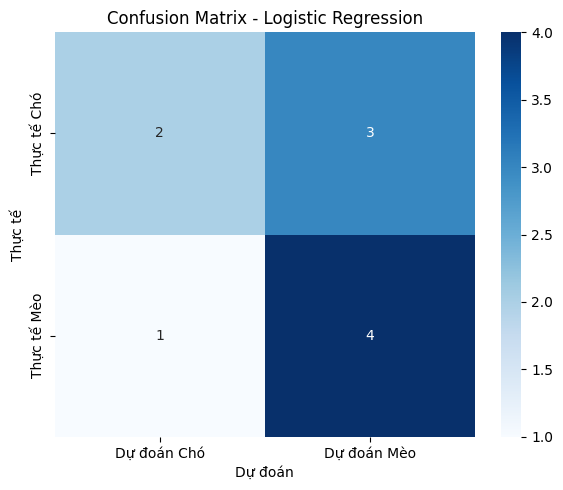

In [3]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog, graycomatrix, graycoprops
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

base_dir = Path(r"D:\DogCat_ML_Project")

def extract_features(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None

    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    avg_color = np.mean(img, axis=(0, 1))
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
    )

    return np.hstack((avg_color, contrast, correlation, hog_features))

def load_split(split_name):
    features = []
    labels = []

    for label in ['dog', 'cat']:
        image_dir = base_dir / 'data' / split_name / label
        for image_path in sorted(image_dir.glob('*')):
            extracted = extract_features(image_path)
            if extracted is not None:
                features.append(extracted)
                labels.append(label)

    return np.array(features), np.array(labels)

X_train, y_train = load_split('train')
X_test, y_test = load_split('test')

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=['dog', 'cat'])

tn = int(cm[1, 1])
fp = int(cm[1, 0])
fn = int(cm[0, 1])
tp = int(cm[0, 0])

print(f"Kết quả trên tập Test:\n")
print(f"o Độ chính xác (Accuracy): {accuracy * 100:.2f}%\n")
print("o Ma trận nhầm lẫn (Confusion Matrix):\n")
print(cm)
print()
print(f"§ True Positive (Đoán đúng Chó): {tp}")
print(f"§ True Negative (Đoán đúng Mèo): {tn}")
print(f"§ False Positive (Nhầm Mèo thành Chó): {fp}")
print(f"§ False Negative (Nhầm Chó thành Mèo): {fn}")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dự đoán Chó', 'Dự đoán Mèo'],
    yticklabels=['Thực tế Chó', 'Thực tế Mèo'],
)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.tight_layout()
plt.show()